In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az

In [2]:
data = get_data()
config, config_str = get_hmc_config(find_min = False, bias = "unified", cap = True, temp = True) # Should change this so i dont have to change here all the time, should do it in define... Also, they are exploring a bit better than you would think now...
find_min_config, find_min_config_str = get_hmc_config(find_min = True)
colors = plt.cm.viridis(np.linspace(0, 1, config["nch"]))

In [3]:
samples = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/samples_{config_str}.npy")
energy_values = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/energy_{config_str}.npy")
bias_values = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/bias_{config_str}.npy")
resampled_samples = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/resamp_{config_str}.npy")

In [4]:
starting_points = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/samples_min_dc2.00_a1.50_b0.21_nch4_N50_H100_nlsp24_mi100000_dt0.00_gl0.00.npy")
starting_energies = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/Emin_dc2.00_a1.50_b0.21_nch4_N50_H100_nlsp24_mi100000_dt0.00_gl0.00.npy")

In [5]:
# print(starting_points)
print(np.sort(starting_energies))

[ 99.14392047 100.27035141 100.99182225 102.30011854 103.60531593
 103.84283776 104.15477603 108.07934722 110.08682979 110.55836315
 110.60270755 111.12655546 112.81433627 113.02985421 113.43417566
 117.3590922  121.45849165 124.80025253 139.28091344 165.64303584
 166.4552278  183.32314474 188.62762058 191.23859206]


In [6]:
print(np.shape(resampled_samples))
print(np.shape(samples))

(5, 9990, 50)
(5, 10000, 50)


In [7]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [8]:
print(energy_values)

[[ 93.69195957  95.94894723 104.99477207 ... 201.57619577 202.13059988
  203.94589752]
 [117.58850465 105.58098762 105.68796087 ... 190.05098791 193.54581657
  195.98001378]
 [101.17571235 104.7732654  103.05126384 ... 213.74448383 216.51661877
  204.10256276]
 [115.65485596 113.69821815 115.57524879 ... 242.91476319 237.99049835
  241.80279608]
 [101.77750444  96.98457517  96.5978314  ... 212.46366511 213.10909983
  220.02820241]]


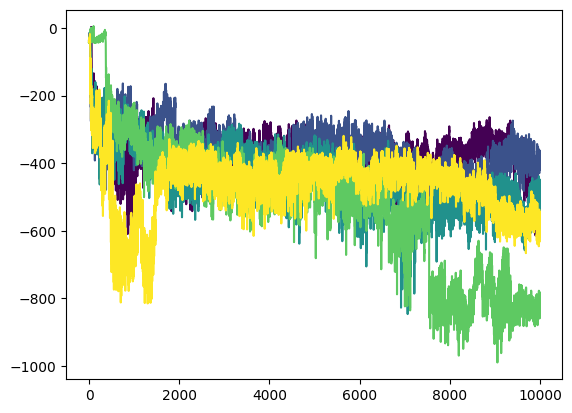

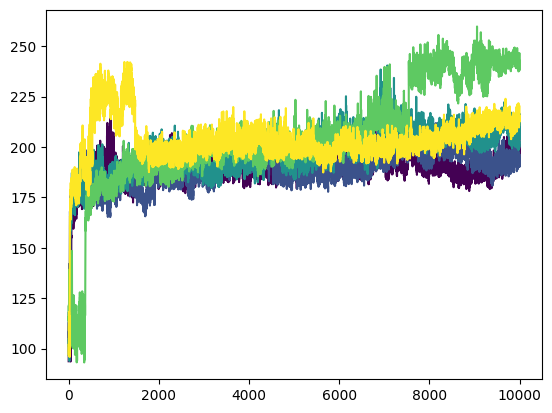

In [9]:
plt.figure()
for i in range(config["nch"]):
    plt.plot(bias_values[i,:], color = colors[i])
plt.show()

plt.figure()
for i in range(config["nch"]):
    plt.plot(energy_values[i,:], color = colors[i])
plt.show()


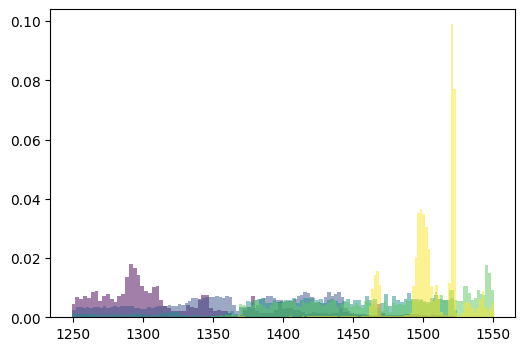

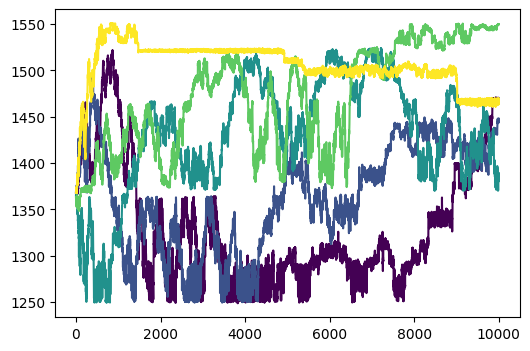

In [10]:
CV_values = data["theta"] - config["dc"] * np.sum(samples[:, :, :45], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
plt.show()

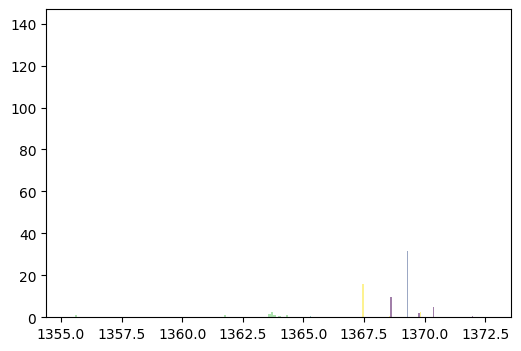

In [11]:
CV_values = data["theta"] - config["dc"] * np.sum(resampled_samples[:, :, :45], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

In [12]:
resampled_samples = resampled_samples[:,::100,:]

In [13]:
print(np.max(bias_values))

4.618984055310335


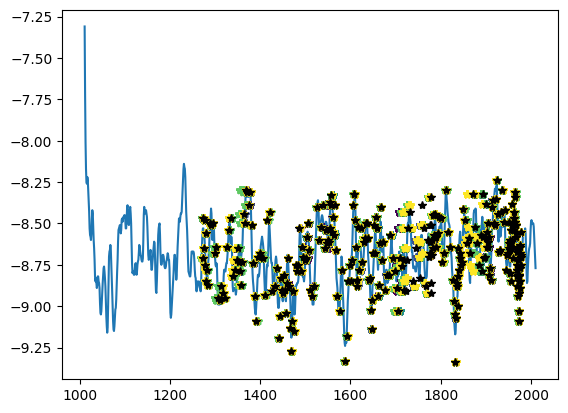

In [14]:
indices = []
for i in range(len(data["d18O_depths"])):
    index = get_index(config["N"], config["cs"], data["d18O_depths"], i)
    indices.append(index)

plt.figure()
plt.plot(data["d18O_reference_times"], data["d18O_reference"])
for i in range(config["nch"]):
    variables = resampled_samples[i,:,:]
    for j in range(len(variables)):
        d18O_ages = expected_ages(config["N"], config["dc"], config["cs"], data["theta"], len(data["d18O_depths"]), data["d18O_depths"], variables[j,:], indices)
        plt.plot(d18O_ages, data["d18O"], '*', color = colors[i])

plt.plot(data["true_ages_D18O"], data["d18O"], '*', color = "k")
plt.show()

In [15]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(resampled_samples)
summary = az.summary(idata, round_to=2)
print(summary)

        mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]    2.74  0.27    2.48     3.19       0.11     0.07      6.90      7.04   
x[1]    4.56  0.51    3.43     5.46       0.20     0.10      6.21     28.56   
x[2]    5.75  0.47    5.08     6.59       0.18     0.05      7.38     48.57   
x[3]    6.24  0.35    5.60     6.78       0.11     0.05     10.81     25.12   
x[4]    7.02  0.54    6.26     7.65       0.20     0.07      8.23      6.35   
x[5]    4.45  0.76    3.57     5.71       0.32     0.16      6.24      6.58   
x[6]    4.78  0.90    3.63     5.82       0.38     0.10      6.55     10.19   
x[7]    2.52  0.73    1.58     3.78       0.31     0.17      5.83     23.47   
x[8]    3.68  1.55    2.15     6.48       0.66     0.39      5.77      5.43   
x[9]    5.92  2.22    3.58     9.98       0.95     0.60      5.77      5.43   
x[10]   6.64  1.61    4.55     9.20       0.68     0.34      5.85      5.43   
x[11]  10.29  2.88    4.71    12.55       1.23     0

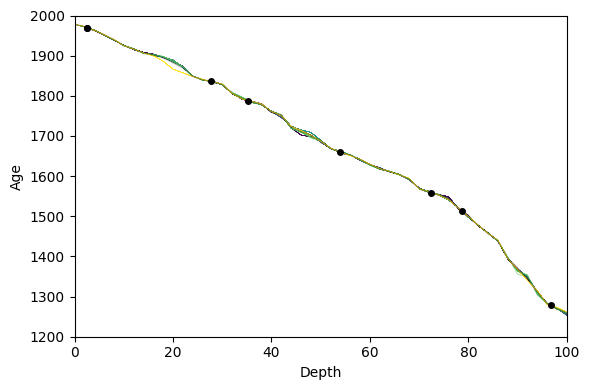

In [16]:
cumulative_sums = np.cumsum(resampled_samples[:, :,:], axis=2) * config["dc"]
zeros = np.zeros((*resampled_samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(resampled_samples[0,:,0])
for i in range(config["nch"]):
    for j in range(num_samples):
        ax.plot(
            config["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )
# for i, c in enumerate(config["cs"]):
#     if i != config["pidx"]:
#         ax.axvline(x=c, color='k', linestyle='--')
#     else:
#         ax.axvline(x=c, color='r', linestyle='--')

ax.set_xlim(0, np.max(config["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

In [ ]:
# TODO: Add the correct solution for plotting here, like with the sedimentation rates computation. 
# Try starting outside the minima? Stochastic gradients here as well? Change CV to what you computed in stochastic.